# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
try:
  import google.colab
  RUN_ENV = 'colab'
except ImportError:
  RUN_ENV = 'local'

In [3]:
COLAB_KAGGLE_UTILS_PATH = '/content/drive/MyDrive/KaggleData'
LOCAL_KAGGLE_UTILS_PATH = '/home/sameera/Projects'
COMP = 's6e8'

In [4]:
import sys

if RUN_ENV == 'colab':
    sys.path.append(COLAB_KAGGLE_UTILS_PATH)
    dataPath = '/content/drive/MyDrive/KaggleData/' + COMP + '/'
else:
    sys.path.append(LOCAL_KAGGLE_UTILS_PATH)
    dataPath = '/home/sameera/Projects/Kaggle/data/KaggleData/' + COMP + '/'

In [5]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Custom utilities
from kaggle_utils.data.visualiser import DataVisualizer

In [6]:
train = pd.read_csv(dataPath + 'train.csv', low_memory=False)
test = pd.read_csv(dataPath + 'test.csv', low_memory=False)
sample_submission = pd.read_csv(dataPath + 'sample_submission.csv', index_col='id', low_memory=False)

# Data glimpse

In [7]:
train.shape, test.shape, sample_submission.shape

((691369, 14), (296302, 13), (296302, 1))

In [8]:
train.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [9]:
test.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


In [10]:
sample_submission.head()

,addicted_label
id,
691369,0.709424
691370,0.709424
691371,0.709424
691372,0.709424
691373,0.709424


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296302 entries, 0 to 296301
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       296302 non-null  int64  
 1   age                      279164 non-null  float64
 2   daily_screen_time_hours  263514 non-null  float64
 3   social_media_hours       248905 non-null  float64
 4   gaming_hours             236882 non-null  float64
 5   work_study_hours         268525 non-null  float64
 6   sleep_hours              273847 non-null  float64
 7   notifications_per_day    262081 non-null  float64
 8   app_opens_per_day        270597 non-null  float64
 9   weekend_screen_time      245605 non-null  float64
 10  gender                   282090 non-null  object 
 11  stress_level             276676 non-null  object 
 12  academic_work_impact     270581 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 29.4+ MB


# Data stats

In [13]:
visualiser = DataVisualizer(train, test)

In [14]:
visualiser.get_stats()

,count,mean,std,min,25%,50%,75%,max
id,691369.000000,345684.000000,199581.183467,0.000000,172842.000000,345684.000000,518526.000000,691368.000000
age,662440.000000,26.615408,5.153162,18.000000,22.000000,27.000000,31.000000,35.000000
daily_screen_time_hours,595515.000000,7.640865,2.721446,0.500000,5.480000,7.770000,9.840000,15.000000
social_media_hours,557374.000000,2.471038,1.316137,0.000000,1.450000,2.310000,3.370000,8.000000
gaming_hours,564548.000000,1.459265,0.934552,0.000000,0.700000,1.330000,2.090000,4.000000
work_study_hours,639851.000000,2.366971,1.258797,0.000000,1.360000,2.200000,3.200000,6.000000
sleep_hours,646889.000000,6.804334,1.234512,4.500000,5.780000,6.800000,7.870000,9.000000
notifications_per_day,623785.000000,145.894900,65.917556,20.000000,93.000000,150.000000,204.000000,250.000000
app_opens_per_day,610659.000000,102.636781,48.093970,15.000000,64.000000,104.000000,145.000000,180.000000
weekend_screen_time,579306.000000,9.479866,2.856006,0.510000,7.280000,9.580000,11.750000,17.560000


In [15]:
visualiser.get_stats('test')

,count,mean,std,min,25%,50%,75%,max
id,296302.000000,839519.500000,85535.164068,691369.000000,765444.250000,839519.500000,913594.750000,987670.000000
age,279164.000000,26.608689,5.153359,18.000000,22.000000,27.000000,31.000000,35.000000
daily_screen_time_hours,263514.000000,7.640771,2.725921,0.500000,5.460000,7.770000,9.850000,15.000000
social_media_hours,248905.000000,2.471224,1.318143,0.000000,1.450000,2.320000,3.370000,7.850000
gaming_hours,236882.000000,1.457668,0.934727,0.000000,0.690000,1.330000,2.090000,4.000000
work_study_hours,268525.000000,2.365962,1.257023,0.000000,1.360000,2.200000,3.200000,6.000000
sleep_hours,273847.000000,6.801704,1.236080,4.500000,5.770000,6.800000,7.870000,9.000000
notifications_per_day,262081.000000,145.748066,66.014554,20.000000,93.000000,150.000000,204.000000,250.000000
app_opens_per_day,270597.000000,102.656216,48.186200,15.000000,63.000000,104.000000,145.000000,180.000000
weekend_screen_time,245605.000000,9.474575,2.858384,0.510000,7.270000,9.580000,11.750000,17.560000


In [16]:
visualiser.get_summary('train')

,dtypes,missing#,missing%,uniques,count
id,int64,0,0.000000,691369,691369
age,float64,28929,4.184307,18,662440
daily_screen_time_hours,float64,95854,13.864376,1389,595515
social_media_hours,float64,133995,19.381112,721,557374
gaming_hours,float64,126821,18.343461,401,564548
work_study_hours,float64,51518,7.451592,600,639851
sleep_hours,float64,44480,6.433612,451,646889
notifications_per_day,float64,67584,9.775388,231,623785
app_opens_per_day,float64,80710,11.673940,166,610659
weekend_screen_time,float64,112063,16.208855,1437,579306


In [17]:
visualiser.get_summary('test')

,dtypes,missing#,missing%,uniques,count
id,int64,0,0.000000,691369,691369
age,float64,28929,4.184307,18,662440
daily_screen_time_hours,float64,95854,13.864376,1389,595515
social_media_hours,float64,133995,19.381112,721,557374
gaming_hours,float64,126821,18.343461,401,564548
work_study_hours,float64,51518,7.451592,600,639851
sleep_hours,float64,44480,6.433612,451,646889
notifications_per_day,float64,67584,9.775388,231,623785
app_opens_per_day,float64,80710,11.673940,166,610659
weekend_screen_time,float64,112063,16.208855,1437,579306


# Features

In [18]:
train.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [20]:
conts = ['age', 'daily_screen_time_hours', 'social_media_hours','gaming_hours', 'work_study_hours', 'sleep_hours','notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',]
cats = ['gender', 'stress_level', 'academic_work_impact']

target = 'addicted_label'

# Data visualizing

## Continous columns test vs train

/home/sameera/Projects/kaggle_utils/data/visualiser.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


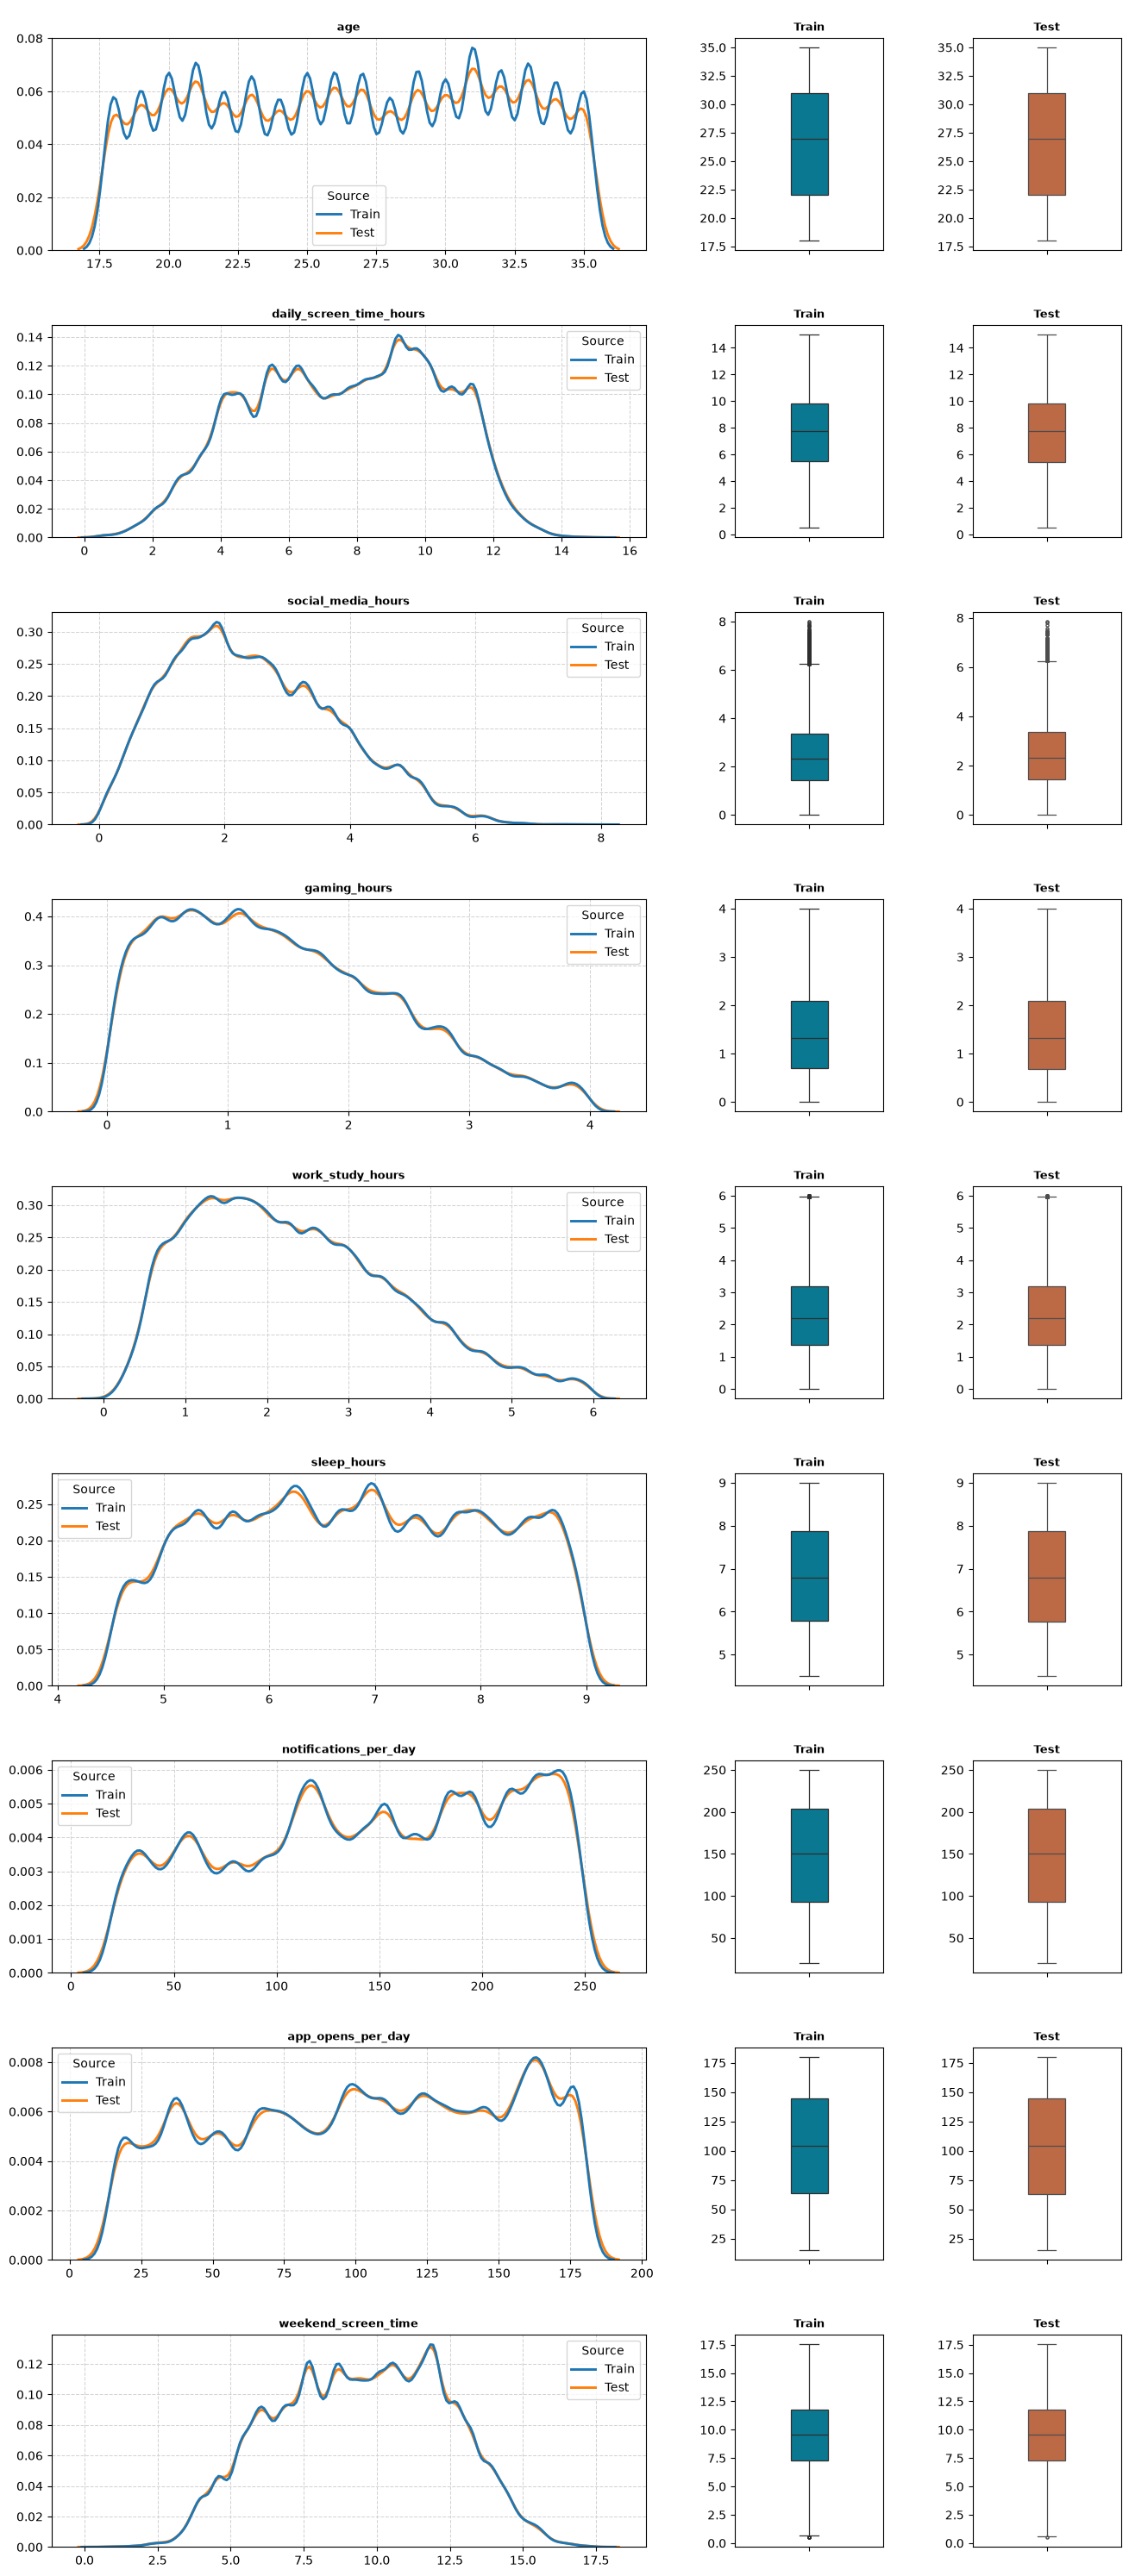

In [21]:
visualiser.plot_train_test_continuous(conts, common_norm = False) # toggle common norm to True to get the same area under the curve for both train and test (True; train+test=1, False; train=1, test=1)

All conts seems to be ok. 

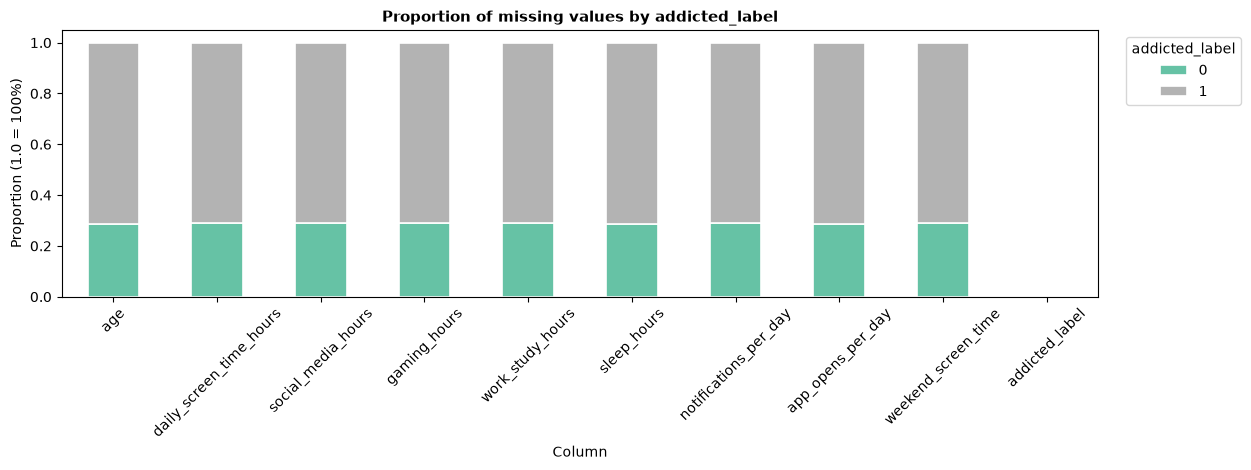

In [29]:
visualiser.plot_missing_by_target(conts, target)

## Train cont vs target

/home/sameera/Projects/kaggle_utils/data/visualiser.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


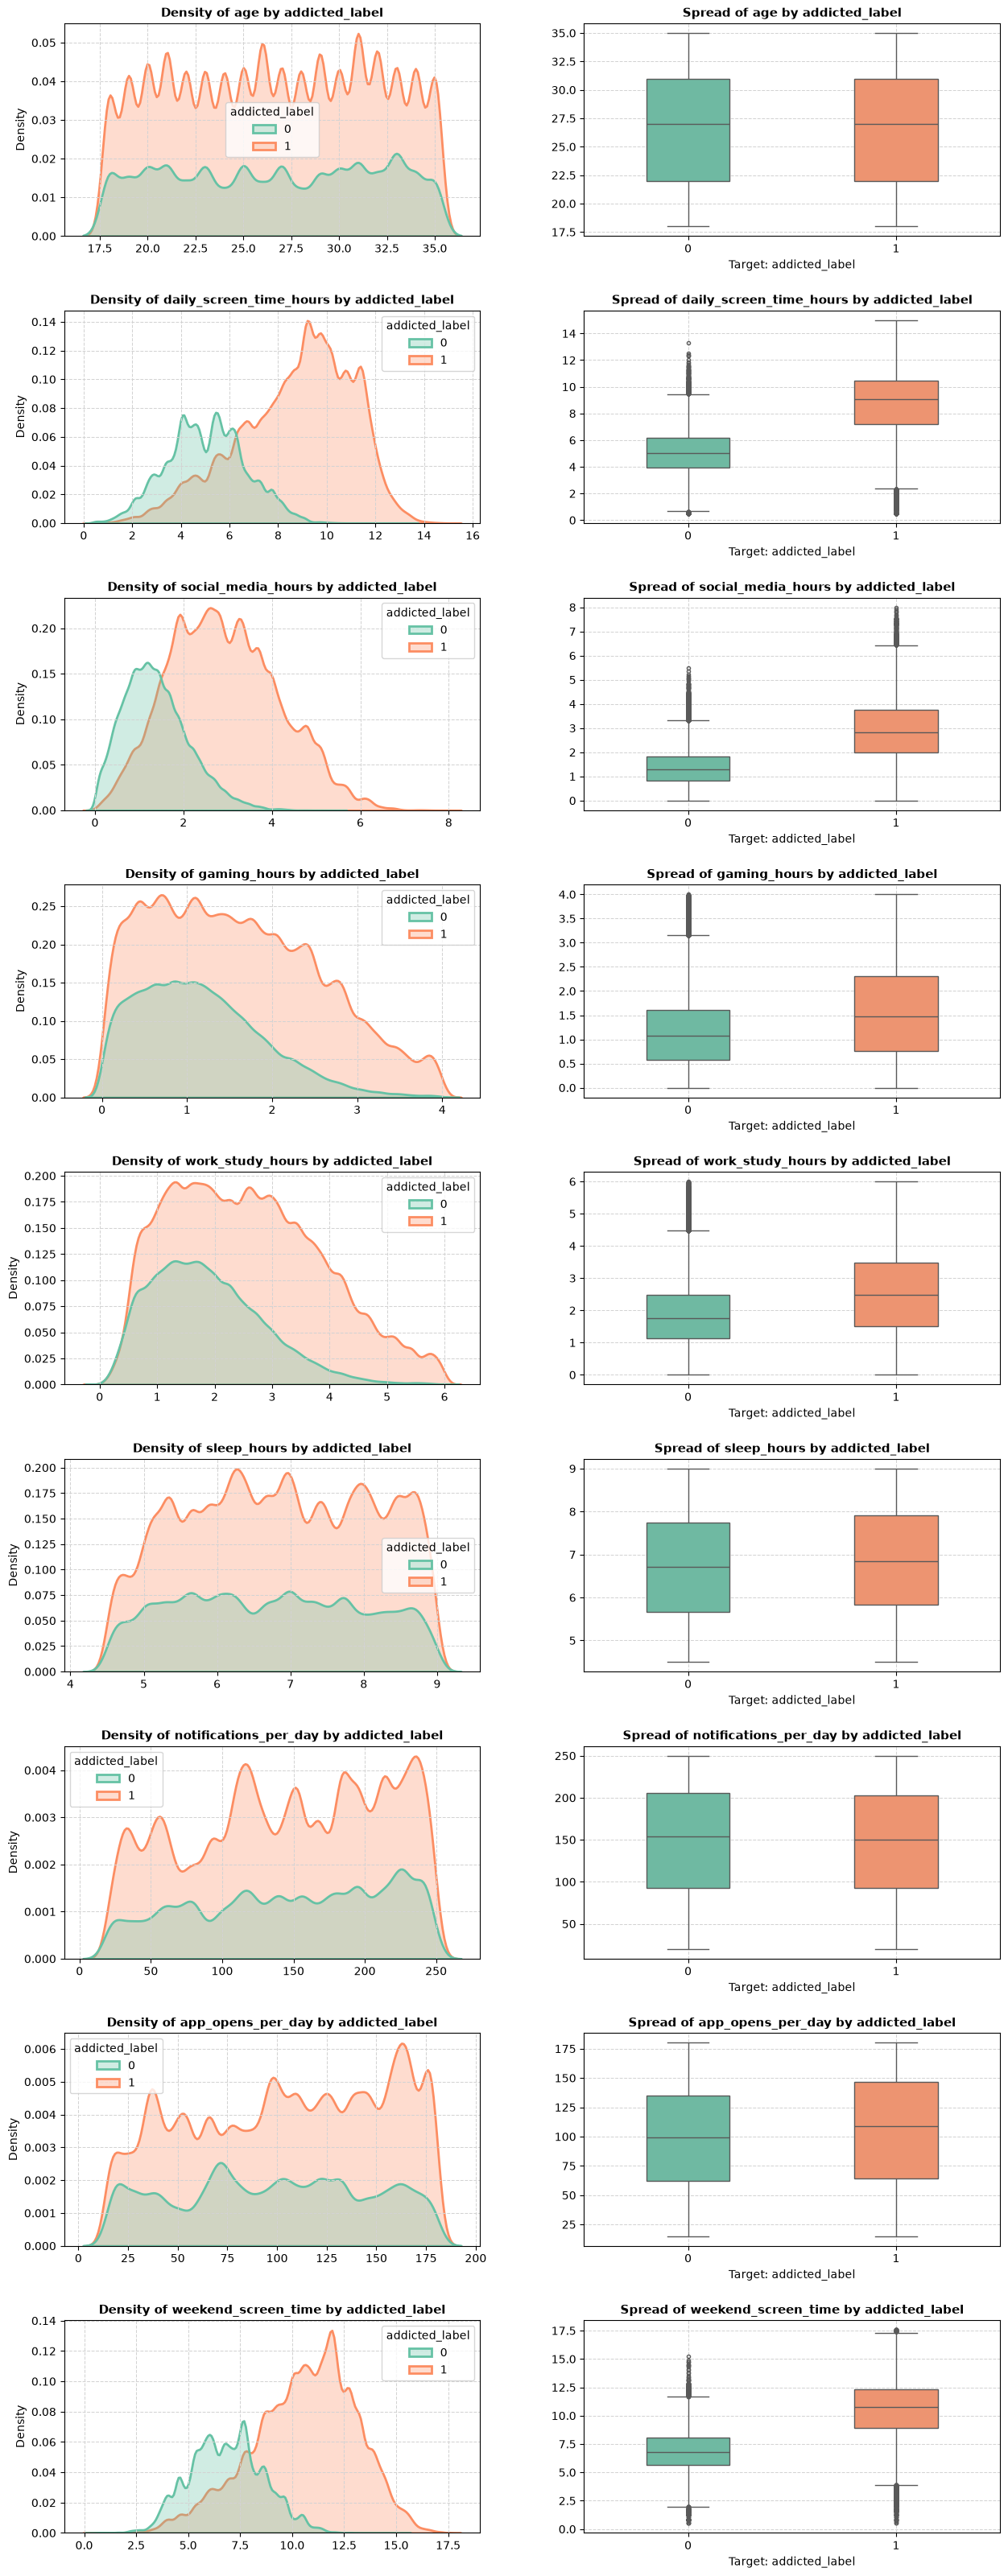

In [22]:
visualiser.plot_continuous_vs_target(conts, target, common_norm = True) # toggle common norm to True to get the same area under the curve for both train and test (True; train+test=1, False; train=1, test=1)

## Categorical train vs test

In [ ]:
from sklearn.impute import SimpleImputer
catImputer = SimpleImputer(strategy='constant', fill_value='missing')
train[cats] = catImputer.fit_transform(train[cats])

/home/sameera/Projects/kaggle_utils/data/visualiser.py:272: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


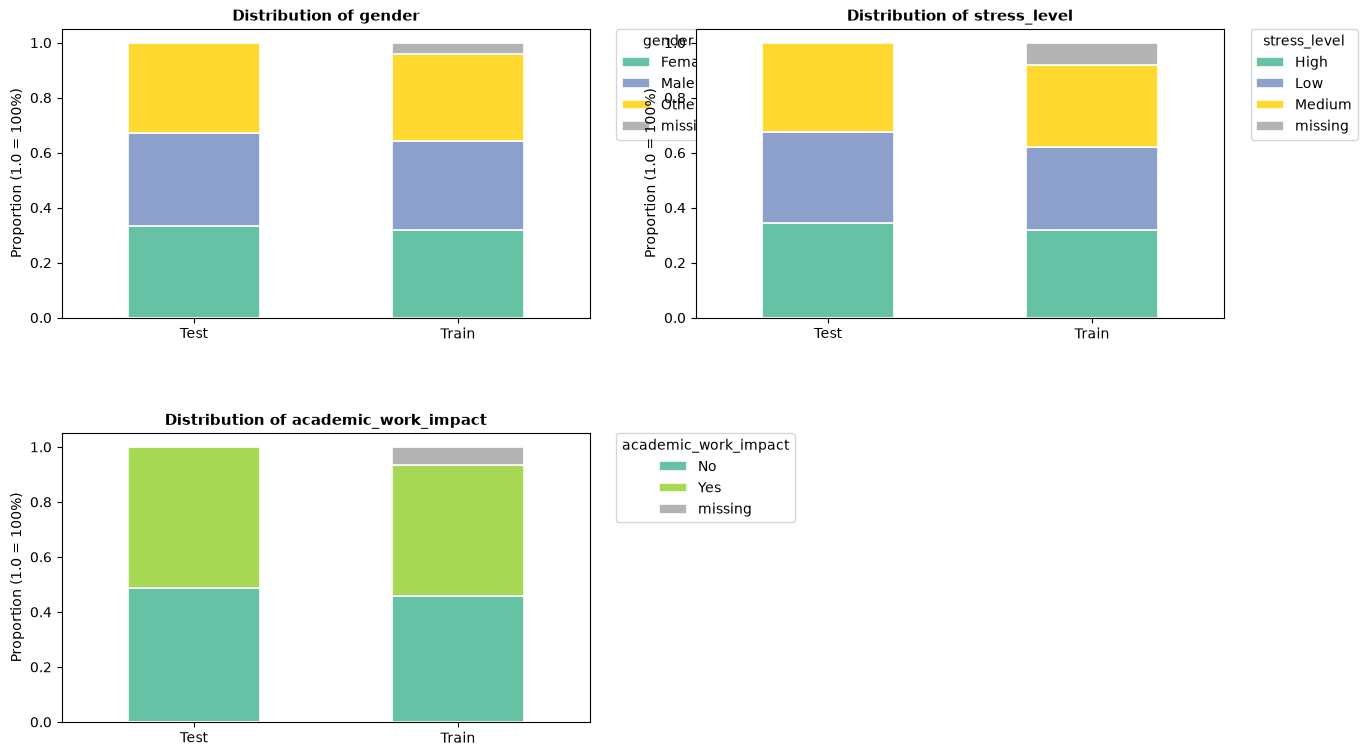

In [27]:
visualiser.plot_categorical_proportions(cats)

## Categorical vs target

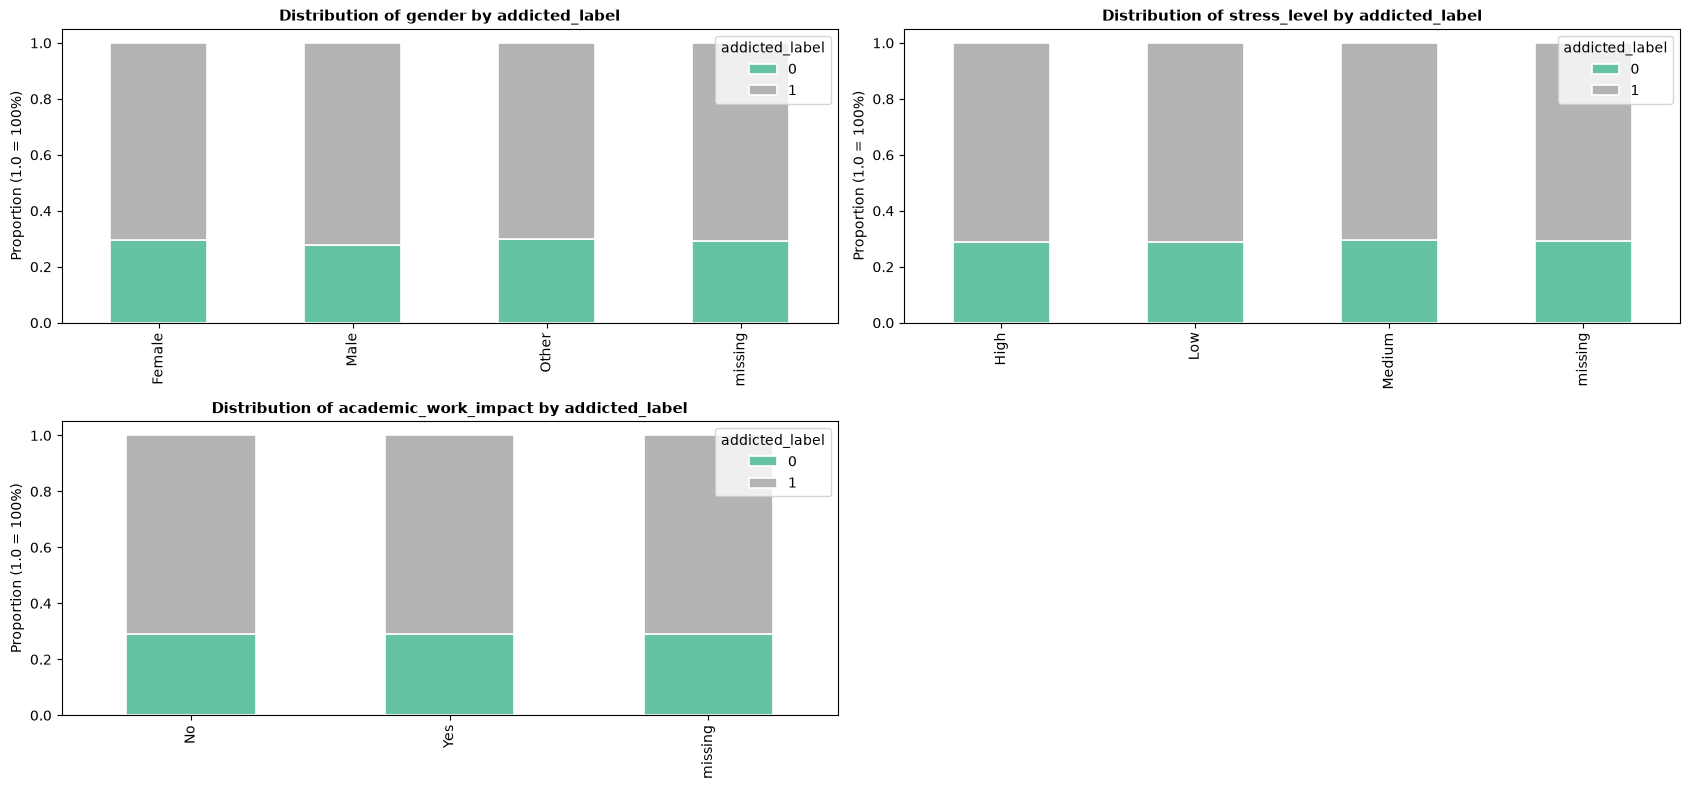

In [28]:
visualiser.plot_count(cats, target)